In [1]:
from pathlib import Path
import time
import json


import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from IPython.display import display, Markdown
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from copy import deepcopy
warnings.filterwarnings("ignore")


In [2]:
# Project configuration

DATA_PATH = Path(
    "/Users/tejaljadhav/Desktop/UCD/Spring2026/Cyber Security/Project/data+models/data/df_reduced_IoT2023.csv"
)

RF_MODEL_PATH = Path(
    "/Users/tejaljadhav/Desktop/UCD/Spring2026/Cyber Security/Project/data+models/models/rf.pkl"
)

XGB_MODEL_PATH = Path(
    "/Users/tejaljadhav/Desktop/UCD/Spring2026/Cyber Security/Project/data+models/models/xgb.pkl"
)

OUTPUT_DIR = Path(
    "/Users/tejaljadhav/Desktop/UCD/Spring2026/Cyber Security/Project/risk_outputs"
)

TEST_SIZE = 0.20
RANDOM_STATE = 42
BATCH_SIZE = 100_000

# Optional user config.
# If user wants custom settings, set this to a JSON file path.
# Example:
# CONFIG_PATH = Path("/Users/tejaljadhav/Desktop/UCD/Spring2026/Cyber Security/Project/risk_config.json")
CONFIG_PATH = None

In [3]:
# Attack severity mapping

# Dictionary mapping attack labels to severity scores.
# Higher values mean more serious attacks.

SEVERITY_BY_LABEL = {
    # No threat
    "BENIGN": 0,

    # Critical: direct compromise / code execution
    "BACKDOOR_MALWARE": 10,
    "COMMANDINJECTION": 10,

    # Very high: data compromise or possible RCE
    "SQLINJECTION": 9,
    "UPLOADING_ATTACK": 9,

     # High: traffic interception, botnet, credential compromise
    "MITM-ARPSPOOFING": 10,
    "MIRAI-GREETH_FLOOD": 8,
    "MIRAI-GREIP_FLOOD": 7,
    "MIRAI-UDPPLAIN": 8,
    "DICTIONARYBRUTEFORCE": 8,

    # High-medium: redirection / client compromise
    "DNS_SPOOFING": 7,
    "XSS": 7,
    "BROWSERHIJACKING": 7,

    # Availability attacks
    "DDOS-SLOWLORIS": 6,
    "DDOS-ICMP_FLOOD": 6,
    "DDOS-UDP_FLOOD": 6,
    "DDOS-TCP_FLOOD": 6,
    "DDOS-PSHACK_FLOOD": 6,
    "DDOS-SYN_FLOOD": 6,
    "DDOS-RSTFINFLOOD": 6,
    "DDOS-SYNONYMOUSIP_FLOOD": 6,
    "DDOS-ICMP_FRAGMENTATION": 6,
    "DDOS-UDP_FRAGMENTATION": 6,
    "DDOS-ACK_FRAGMENTATION": 6,
    "DDOS-HTTP_FLOOD": 6,

    # Single-source DoS
    "DOS-UDP_FLOOD": 5,
    "DOS-TCP_FLOOD": 5,
    "DOS-SYN_FLOOD": 5,
    "DOS-HTTP_FLOOD": 5,

    # Reconnaissance
    "VULNERABILITYSCAN": 4,
    "RECON-PORTSCAN": 3,
    "RECON-OSSCAN": 3,
    "RECON-HOSTDISCOVERY": 2,
    "RECON-PINGSWEEP": 2,
}

# user configuration
# This keeps the default behavior unless CONFIG_PATH is set.
# If a config file is provided, it can override severity values, asset rules and high severity threshold.

DEFAULT_PROTOCOL_ASSET_RULES = [
    {
        "protocols": ["ICMP", "UDP"],
        "asset_target": "generic_or_unknown",
        "asset_value": 3,
    },
    {
        "protocols": ["Telnet", "IRC"],
        "asset_target": "legacy_or_iot_device",
        "asset_value": 5,
    },
    {
        "protocols": ["HTTP", "HTTPS"],
        "asset_target": "web_server",
        "asset_value": 7,
    },
    {
        "protocols": ["SSH", "SMTP", "DNS", "DHCP"],
        "asset_target": "server_or_network_infrastructure",
        "asset_value": 9,
    },
]

DEFAULT_RISK_CONFIG = {
    "severity_map": SEVERITY_BY_LABEL,
    "protocol_asset_rules": DEFAULT_PROTOCOL_ASSET_RULES,
    "default_asset_target": "default",
    "default_asset_value": 2,
    "high_severity_threshold": 7,
}

In [4]:
# Function to use default scoring rules unless a config file is provided.
def load_risk_config(config_path=None):
    config = deepcopy(DEFAULT_RISK_CONFIG)

    if config_path is None:
        print("Using default risk settings.")
        return config

    config_path = Path(config_path)

    if not config_path.exists():
        print(f"Config file not found: {config_path}. Using default risk settings.")
        return config

    with open(config_path, "r") as f:
        user_config = json.load(f)

    for key, value in user_config.items():
        if key == "severity_map":
            config["severity_map"].update(value)
        else:
            config[key] = value

    print(f"Loaded user config from: {config_path}")
    return config


RISK_CONFIG = load_risk_config(CONFIG_PATH)
SEVERITY_BY_LABEL = RISK_CONFIG["severity_map"]
HIGH_SEVERITY_THRESHOLD = RISK_CONFIG["high_severity_threshold"]

Using default risk settings.


In [5]:
# Function to return severity score for an attack label.

def get_severity(label):
    # If label exists in dictionary, return mapped severity.
    if label in SEVERITY_BY_LABEL:
        return SEVERITY_BY_LABEL[label]

    if label.startswith("DDOS-"):
        return 6
    if label.startswith("DOS-"):
        return 5
    if label.startswith("MIRAI-"):
        return 8
    if label.startswith("RECON-"):
        return 3
    
    # Default severity if no match is found.
    return 5

In [6]:
# Load dataset

print("Loading dataset...")
df = pd.read_csv(DATA_PATH)

print(f"Dataset path: {DATA_PATH}")
print(f"Dataset shape: {df.shape}")

# Same setup as teammate's code.
X = df.iloc[:, :-1]

le = LabelEncoder()
y = le.fit_transform(df["Label"]) # Convert attack labels into numeric values.

Loading dataset...
Dataset path: /Users/tejaljadhav/Desktop/UCD/Spring2026/Cyber Security/Project/data+models/data/df_reduced_IoT2023.csv
Dataset shape: (21004674, 30)


In [7]:
# Split dataset into training and testing sets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE, # Percentage reserved for testing.
    random_state=RANDOM_STATE, # Random seed.
    stratify=y,
)

print(f"X_test shape: {X_test.shape}")



X_test shape: (4200935, 29)


In [8]:
# Load saved models

print("Loading models...")
rf_model = joblib.load(RF_MODEL_PATH) # Load Random Forest model.
xgb_model = joblib.load(XGB_MODEL_PATH) # Load XGBoost model.

Loading models...


In [9]:
# Run ensemble inference
# Ensemble = average of RF and XGBoost class probabilities.


n_batches = int(np.ceil(len(X_test) / BATCH_SIZE)) # total number of batches

predictions_ensemble = [] # predicted class labels
probabilities_ensemble = [] # predicted probabilities

start = time.time()

# Process data batch by batch.
for i in range(n_batches):
    start_idx = i * BATCH_SIZE
    end_idx = min(start_idx + BATCH_SIZE, len(X_test))

    X_batch = X_test.iloc[start_idx:end_idx]
    
    # Predict probabilities using Random Forest and XGBoost.
    proba_rf = rf_model.predict_proba(X_batch)
    proba_xgb = xgb_model.predict_proba(X_batch)

    proba_avg = (proba_rf + proba_xgb) / 2 # Average both model probabilities.
    preds = np.argmax(proba_avg, axis=1)  # Select class with highest probability.

    
    probabilities_ensemble.append(proba_avg)
    predictions_ensemble.append(preds)

    print(f"Processed batch {i + 1}/{n_batches}")

elapsed = time.time() - start

# Combine all probability batches and prediction batches.
probabilities_ensemble = np.concatenate(probabilities_ensemble)
predictions_ensemble = np.concatenate(predictions_ensemble)

print(f"Inference time: {elapsed:.2f}s")
print(f"Throughput: {len(X_test) / elapsed:,.0f} samples/sec")
print(f"Average latency: {elapsed / len(X_test) * 1e6:.2f} microseconds/sample")

Processed batch 1/43
Processed batch 2/43
Processed batch 3/43
Processed batch 4/43
Processed batch 5/43
Processed batch 6/43
Processed batch 7/43
Processed batch 8/43
Processed batch 9/43
Processed batch 10/43
Processed batch 11/43
Processed batch 12/43
Processed batch 13/43
Processed batch 14/43
Processed batch 15/43
Processed batch 16/43
Processed batch 17/43
Processed batch 18/43
Processed batch 19/43
Processed batch 20/43
Processed batch 21/43
Processed batch 22/43
Processed batch 23/43
Processed batch 24/43
Processed batch 25/43
Processed batch 26/43
Processed batch 27/43
Processed batch 28/43
Processed batch 29/43
Processed batch 30/43
Processed batch 31/43
Processed batch 32/43
Processed batch 33/43
Processed batch 34/43
Processed batch 35/43
Processed batch 36/43
Processed batch 37/43
Processed batch 38/43
Processed batch 39/43
Processed batch 40/43
Processed batch 41/43
Processed batch 42/43
Processed batch 43/43
Inference time: 49.01s
Throughput: 85,724 samples/sec
Average l

In [10]:
# Compute P(malicious)

# For risk scoring, use malicious probability:
# P(malicious) = 1 - P(BENIGN)

benign_index = list(le.classes_).index("BENIGN") #  index position of BENIGN class.

p_benign = probabilities_ensemble[:, benign_index] # Extract benign probabilities.
p_malicious = 1 - p_benign #  Malicious probability.

# Highest predicted probability among all classes.
predicted_class_probability = probabilities_ensemble.max(axis=1)

predicted_labels = le.inverse_transform(predictions_ensemble)
actual_labels = le.inverse_transform(y_test)

In [11]:
# Add severity scores

predicted_severity = np.array(
    [get_severity(label) for label in predicted_labels]
)

actual_severity = np.array(
    [get_severity(label) for label in actual_labels]
)


In [12]:
# Create protocol-based asset value
# infering asset value from protocol columns.
# Default rules are used unless a config file overrides them.

# Function to check if protocol columns are active.
def protocol_mask(data, columns, threshold=0.5):

    # Keep only protocol columns that exist in dataframe.
    available = [col for col in columns if col in data.columns]

    if not available:
        return pd.Series(False, index=data.index)

    return data[available].ge(threshold).any(axis=1)  # Return True if any protocol value exceeds threshold.


asset_value = pd.Series(
    RISK_CONFIG["default_asset_value"],
    index=X_test.index,
    dtype=int,
)

asset_target = pd.Series(
    RISK_CONFIG["default_asset_target"],
    index=X_test.index,
    dtype=object,
)

for rule in RISK_CONFIG["protocol_asset_rules"]:
    mask = protocol_mask(X_test, rule["protocols"])
    asset_value.loc[mask] = rule["asset_value"]
    asset_target.loc[mask] = rule["asset_target"]

asset_value = asset_value.to_numpy()
asset_target = asset_target.to_numpy()


In [13]:
# Compute final risk score
# Risk score formula: probability × severity × asset value

risk_score = p_malicious * predicted_severity * asset_value

In [14]:
# Build alert table

alerts = pd.DataFrame(
    {
        "sample_index": X_test.index,
        "actual_label": actual_labels,
        "predicted_label": predicted_labels,
        "predicted_class_probability": predicted_class_probability,
        "p_benign": p_benign,
        "p_malicious": p_malicious,
        "predicted_severity": predicted_severity,
        "actual_severity": actual_severity,
        "asset_target": asset_target,
        "asset_value": asset_value,
        "risk_score": risk_score,
    }
)

alerts["actual_is_malicious"] = alerts["actual_label"] != "BENIGN" # True if attack is malicious.
alerts["actual_is_high_severity"] = alerts["actual_severity"] >= HIGH_SEVERITY_THRESHOLD # True if attack severity is high.
alerts["fifo_order"] = np.arange(len(alerts)) # FIFO ordering column.

In [15]:
# Rank alerts

ranked_by_risk = alerts.sort_values("risk_score", ascending=False) # Rank by highest risk score.
ranked_by_probability = alerts.sort_values("p_malicious", ascending=False) # Rank by malicious probability.
ranked_by_severity = alerts.sort_values("predicted_severity", ascending=False) # Rank by severity only.
ranked_fifo = alerts.sort_values("fifo_order", ascending=True) # Rank by FIFO order.

In [16]:
display(Markdown("## Dataset Overview"))
total = len(alerts)
malicious = alerts["actual_is_malicious"].sum()
high_sev = alerts["actual_is_high_severity"].sum()
print("=========================================================")
print(f" Total alerts in test set : {total:,}")
print(f" Malicious alerts         : {malicious:,} ({malicious/total*100:.1f}%)")
print(f" High severity alerts     : {high_sev:,} ({high_sev/total*100:.1f}%)")
print("=========================================================")

## Dataset Overview

 Total alerts in test set : 4,200,935
 Malicious alerts         : 3,991,473 (95.0%)
 High severity alerts     : 566,293 (13.5%)


<h2 style='text-align:center;'> Attack Type Distribution in Test Set</h2>

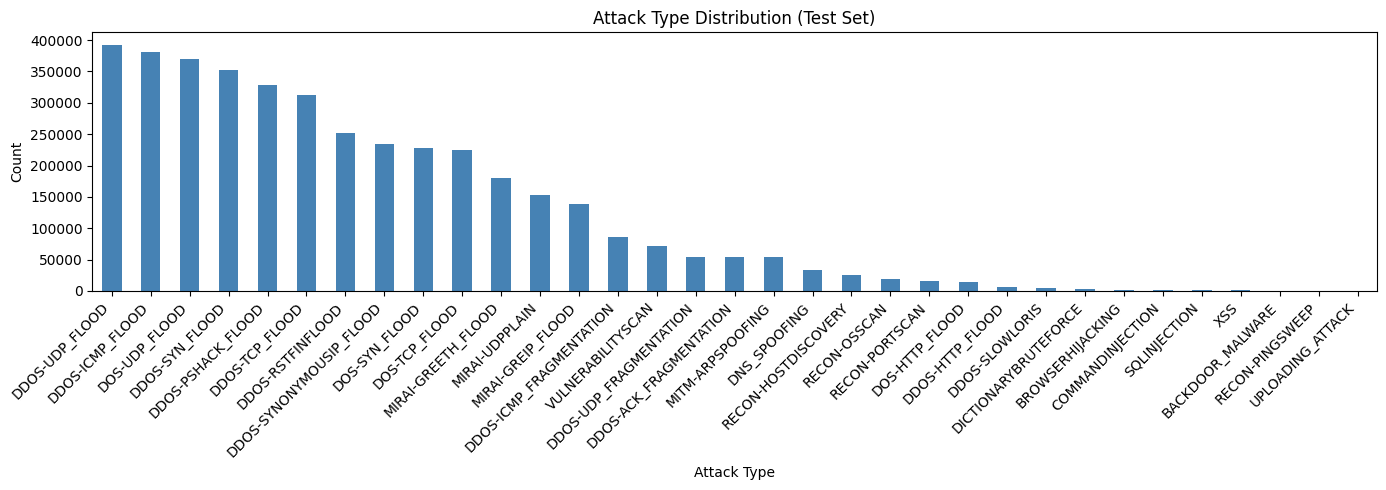

In [17]:
display(Markdown(
    "<h2 style='text-align:center;'> Attack Type Distribution in Test Set</h2>"
))
attack_counts = alerts[alerts["actual_is_malicious"]]["actual_label"].value_counts()

plt.figure(figsize=(14, 5))
attack_counts.plot(kind="bar", color="steelblue")
plt.title("Attack Type Distribution (Test Set)")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [18]:
# Display top 20 alerts.
display_table = ranked_by_risk.head(20).copy()

# Renaming columns for better readability.
display_table = display_table.rename(
    columns={
        "predicted_label": "Attack Type",
        "p_malicious": "Attack Probability",
        "predicted_severity": "Severity",
        "asset_target": "Asset Type",
        "asset_value": "Asset Value",
        "risk_score": "Final Risk Score",
    }
)

# Add ranking column.
display_table.insert(0, "Priority", range(1, len(display_table) + 1))

display_table = display_table[
    [
        "Priority",
        "Attack Type",
        "Attack Probability",
        "Severity",
        "Asset Type",
        "Asset Value",
        "Final Risk Score",
    ]
]

display(Markdown("""
### Risk Score Color Legend
- 🟥 Dark Red → Highest Final Risk Score
- 🟧 Medium Red → Medium Risk Score
- ⬜ Light Red → Lower Risk Score

Darker shades indicate more critical alerts.
"""))

display(Markdown(
    "<h2 style='text-align:center;'>Top 20 Highest Priority Alerts Ranked by Risk Layer</h2>"
))

display(
    display_table.style.format(
        {
            "Attack Probability": "{:.2%}",
            "Final Risk Score": "{:.2f}",
        }
    ).background_gradient(
        subset=["Final Risk Score"],
        cmap="Reds",
    )
)


### Risk Score Color Legend
- 🟥 Dark Red → Highest Final Risk Score
- 🟧 Medium Red → Medium Risk Score
- ⬜ Light Red → Lower Risk Score

Darker shades indicate more critical alerts.


<h2 style='text-align:center;'>Top 20 Highest Priority Alerts Ranked by Risk Layer</h2>

,Priority,Attack Type,Attack Probability,Severity,Asset Type,Asset Value,Final Risk Score
2452664,1,MITM-ARPSPOOFING,99.76%,10,server_or_network_infrastructure,9,89.78
1760201,2,MITM-ARPSPOOFING,99.76%,10,server_or_network_infrastructure,9,89.78
294994,3,MITM-ARPSPOOFING,99.75%,10,server_or_network_infrastructure,9,89.78
712208,4,MITM-ARPSPOOFING,99.74%,10,server_or_network_infrastructure,9,89.76
49102,5,MITM-ARPSPOOFING,99.72%,10,server_or_network_infrastructure,9,89.74
153003,6,MITM-ARPSPOOFING,99.70%,10,server_or_network_infrastructure,9,89.73
1153193,7,MITM-ARPSPOOFING,99.68%,10,server_or_network_infrastructure,9,89.71
2099609,8,MITM-ARPSPOOFING,99.62%,10,server_or_network_infrastructure,9,89.65
4117959,9,MITM-ARPSPOOFING,99.61%,10,server_or_network_infrastructure,9,89.65
859312,10,MITM-ARPSPOOFING,99.59%,10,server_or_network_infrastructure,9,89.63


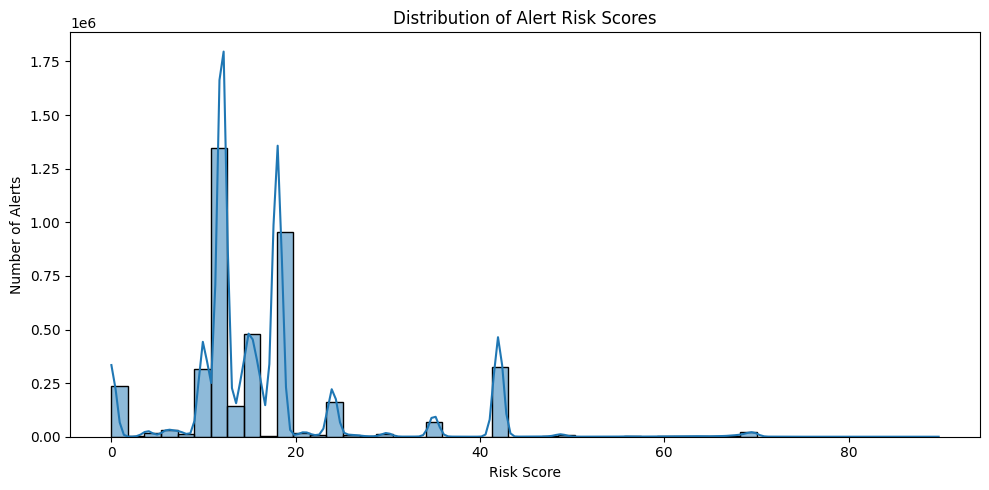

In [19]:
plt.figure(figsize=(10, 5))
sns.histplot(alerts["risk_score"], bins=50, kde=True)
plt.title("Distribution of Alert Risk Scores")
plt.xlabel("Risk Score")
plt.ylabel("Number of Alerts")
plt.tight_layout()
plt.show()

In [20]:
# Function to compute Precision@K and Recall@K.

def precision_recall_at_k(ranked_alerts, relevant_column, k):
    top_k = ranked_alerts.head(k) # Select top K alerts.

    relevant_found = int(top_k[relevant_column].sum())
    total_relevant = int(alerts[relevant_column].sum())

    precision = relevant_found / k if k > 0 else 0
    recall = relevant_found / total_relevant if total_relevant > 0 else 0

    return precision, recall, relevant_found, total_relevant


k_values = [100, 500, 1000, 5000, 10000]

ranking_methods = {
    "risk_score": ranked_by_risk,
    "probability_only": ranked_by_probability,
    "severity_only": ranked_by_severity,
    "fifo": ranked_fifo,
}

metric_rows = []

for method_name, ranked_alerts in ranking_methods.items():
    for relevant_column in ["actual_is_malicious", "actual_is_high_severity"]:
        for k in k_values:
            precision, recall, found, total = precision_recall_at_k(
                ranked_alerts,
                relevant_column,
                k,
            )

            metric_rows.append(
                {
                    "method": method_name,
                    "relevance_target": relevant_column,
                    "k": k,
                    "precision_at_k": precision,
                    "recall_at_k": recall,
                    "relevant_found": found,
                    "total_relevant": total,
                }
            )

ranking_metrics = pd.DataFrame(metric_rows)

In [21]:
styled_table = (
    ranking_metrics.style
    .format({
        "precision_at_k": "{:.2%}",
        "recall_at_k": "{:.4%}",
    })
    .background_gradient(
        subset=["precision_at_k"],
        cmap="Greens"
    )
    .background_gradient(
        subset=["recall_at_k"],
        cmap="Blues"
    )
    .set_properties(**{
        "text-align": "center",
        "font-size": "12pt"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#222"),
                ("color", "white"),
                ("font-size", "13pt")
            ]
        }
    ])
)
display(Markdown("""
<span style='color:#00cc44'><b>■ Dark Green</b></span> = Higher Precision@K  
<span style='color:#1f77ff'><b>■ Dark Blue</b></span> = Higher Recall@K  
Light shades = Lower metric values
"""))
display(Markdown(
    "<h2 style='text-align:center;'>Ranking Metrics Dashboard</h2>"
))
display(styled_table)


<span style='color:#00cc44'><b>■ Dark Green</b></span> = Higher Precision@K  
<span style='color:#1f77ff'><b>■ Dark Blue</b></span> = Higher Recall@K  
Light shades = Lower metric values


<h2 style='text-align:center;'>Ranking Metrics Dashboard</h2>

,method,relevance_target,k,precision_at_k,recall_at_k,relevant_found,total_relevant
0,risk_score,actual_is_malicious,100,98.00%,0.0025%,98,3991473
1,risk_score,actual_is_malicious,500,96.80%,0.0121%,484,3991473
2,risk_score,actual_is_malicious,1000,98.40%,0.0247%,984,3991473
3,risk_score,actual_is_malicious,5000,99.68%,0.1249%,4984,3991473
4,risk_score,actual_is_malicious,10000,99.82%,0.2501%,9982,3991473
5,risk_score,actual_is_high_severity,100,83.00%,0.0147%,83,566293
6,risk_score,actual_is_high_severity,500,89.80%,0.0793%,449,566293
7,risk_score,actual_is_high_severity,1000,94.70%,0.1672%,947,566293
8,risk_score,actual_is_high_severity,5000,98.90%,0.8732%,4945,566293
9,risk_score,actual_is_high_severity,10000,99.39%,1.7551%,9939,566293


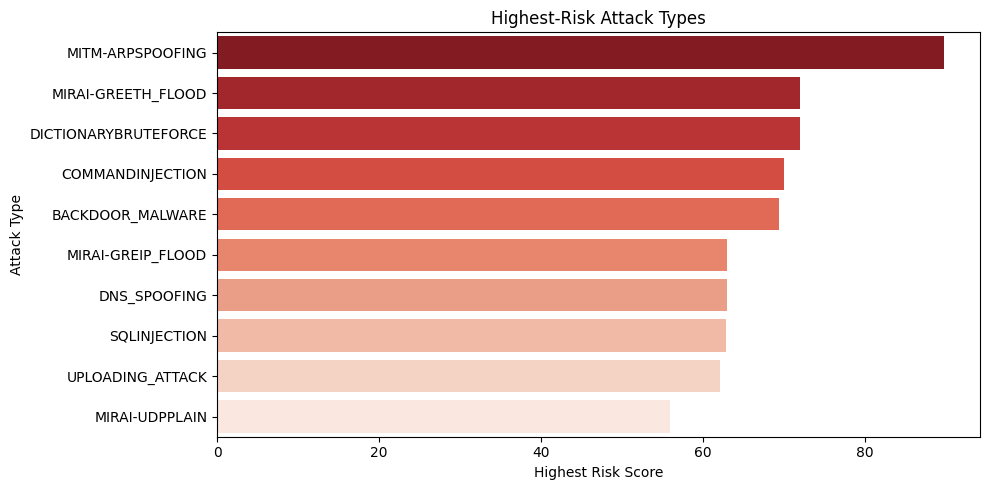

In [22]:
top_attack_types = (
    ranked_by_risk
    .groupby("predicted_label", as_index=False)
    .agg(
        highest_risk_score=("risk_score", "max"),
        average_risk_score=("risk_score", "mean"),
        number_of_alerts=("risk_score", "count"),
        average_attack_probability=("p_malicious", "mean"),
        severity=("predicted_severity", "max"),
        asset_value=("asset_value", "max"),
    )
    .sort_values("highest_risk_score", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_attack_types,
    x="highest_risk_score",
    y="predicted_label",
    palette="Reds_r"
)

plt.title("Highest-Risk Attack Types")
plt.xlabel("Highest Risk Score")
plt.ylabel("Attack Type")
plt.tight_layout()
plt.show()


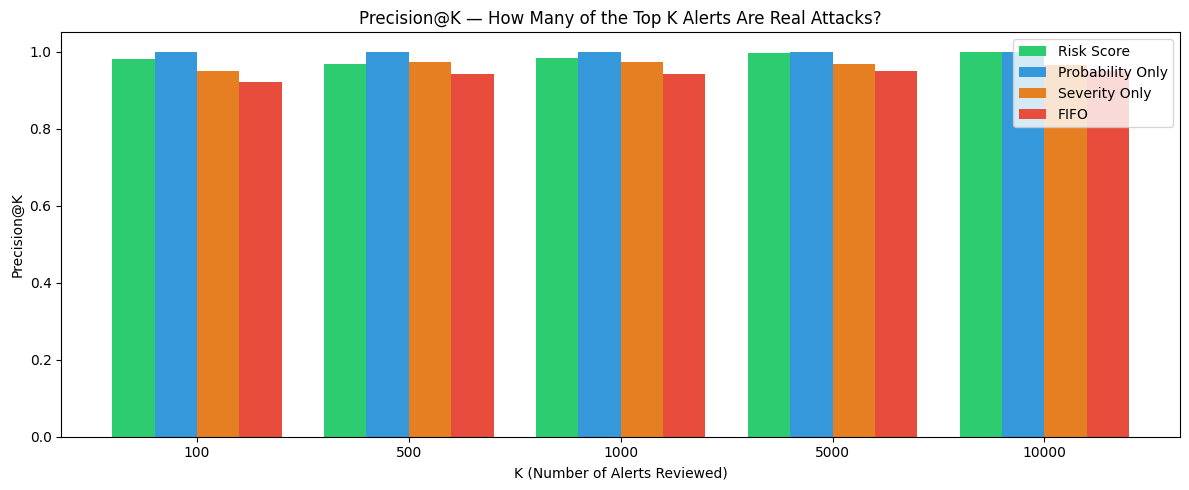

In [23]:
plot_data = ranking_metrics[
    ranking_metrics["relevance_target"] == "actual_is_malicious"
]

methods = ["risk_score", "probability_only", "severity_only", "fifo"]
method_labels = ["Risk Score", "Probability Only", "Severity Only", "FIFO"]
colors = ["#2ecc71", "#3498db", "#e67e22", "#e74c3c"]
k_values = [100, 500, 1000, 5000, 10000]  # matches what was computed

x = np.arange(len(k_values))
width = 0.2

plt.figure(figsize=(12, 5))
for i, (method, label, color) in enumerate(zip(methods, method_labels, colors)):
    vals = plot_data[plot_data["method"] == method]["precision_at_k"].values
    plt.bar(x + i * width, vals, width, label=label, color=color)

plt.title("Precision@K — How Many of the Top K Alerts Are Real Attacks?")
plt.xlabel("K (Number of Alerts Reviewed)")
plt.ylabel("Precision@K")
plt.xticks(x + width * 1.5, [str(k) for k in k_values])
plt.legend()
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig("ranking_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

<h2 style='text-align:center;'>Precision@K — High Severity Attacks</h2>

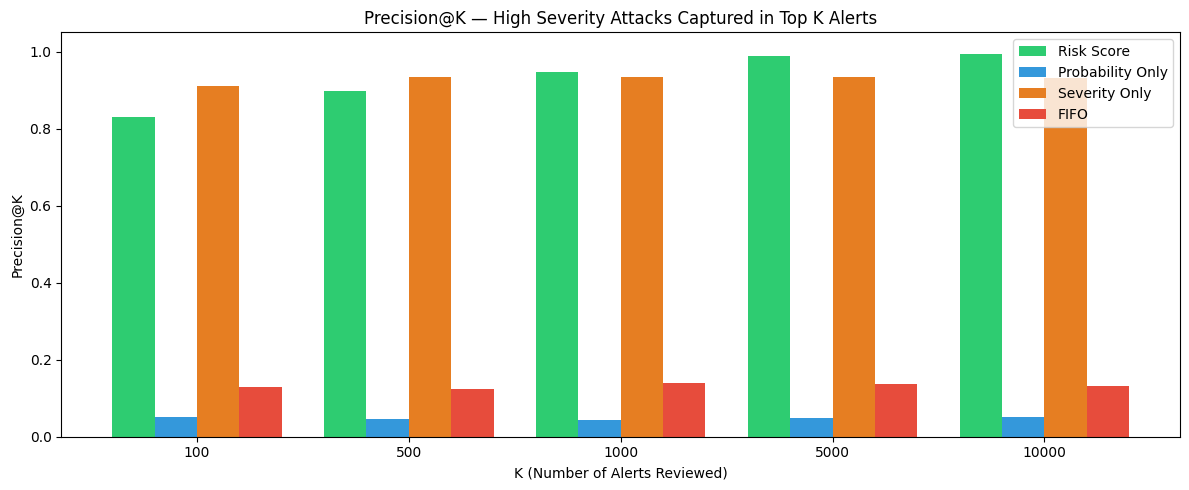

In [24]:
display(Markdown(
    "<h2 style='text-align:center;'>Precision@K — High Severity Attacks</h2>"
))
plot_data_hs = ranking_metrics[
    ranking_metrics["relevance_target"] == "actual_is_high_severity"
]

k_values = [100, 500, 1000, 5000, 10000]
methods = ["risk_score", "probability_only", "severity_only", "fifo"]
method_labels = ["Risk Score", "Probability Only", "Severity Only", "FIFO"]
colors = ["#2ecc71", "#3498db", "#e67e22", "#e74c3c"]

x = np.arange(len(k_values))
width = 0.2

plt.figure(figsize=(12, 5))
for i, (method, label, color) in enumerate(zip(methods, method_labels, colors)):
    vals = plot_data_hs[plot_data_hs["method"] == method]["precision_at_k"].values
    plt.bar(x + i * width, vals, width, label=label, color=color)

plt.title("Precision@K — High Severity Attacks Captured in Top K Alerts")
plt.xlabel("K (Number of Alerts Reviewed)")
plt.ylabel("Precision@K")
plt.xticks(x + width * 1.5, [str(k) for k in k_values])
plt.legend()
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [25]:
# Save outputs

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ranked_by_risk.head(10000).to_csv(
    OUTPUT_DIR / "ranked_alerts_top_10000.csv",
    index=False,
)

ranking_metrics.to_csv(
    OUTPUT_DIR / "ranking_metrics.csv",
    index=False,
)

# Final summary


print("\nRisk formula:")
print("risk_score = P(malicious) * predicted_severity * asset_value")
print("P(malicious) = 1 - P(BENIGN)")

print("\nFiles saved:")
print(OUTPUT_DIR / "ranked_alerts_top_10000.csv")
print(OUTPUT_DIR / "ranking_metrics.csv")


Risk formula:
risk_score = P(malicious) * predicted_severity * asset_value
P(malicious) = 1 - P(BENIGN)

Files saved:
/Users/tejaljadhav/Desktop/UCD/Spring2026/Cyber Security/Project/risk_outputs/ranked_alerts_top_10000.csv
/Users/tejaljadhav/Desktop/UCD/Spring2026/Cyber Security/Project/risk_outputs/ranking_metrics.csv
